<a href="https://colab.research.google.com/github/Ilya-creat/python-group-progject2/blob/colab/GP2_Analyse_Ainur.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Программирование на Python, БИ

## НИУ ВШЭ, 2025-26 учебный год

# Групповой проект №2. DE: Scraping & API

### Общая информация

Дата выдачи: 21.10.2025

Защита проекта: 12.11.2025

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
df = pd.read_csv('bk_offers_hist_normal-20251106_160848.csv')

In [ ]:
agg = df.groupby(['event_id', 'outcome_name', 'snapshot_time'])['outcome_odds'].mean().reset_index()
final_df = agg.pivot_table(index=['event_id', 'outcome_name'], columns='snapshot_time', values='outcome_odds').reset_index()
means_df = final_df.rename(columns={
    'default': 'mean_odds_default',
    '1h_before': 'mean_odds_1h_before',
    '4h_before': 'mean_odds_4h_before',
    '12h_before': 'mean_odds_12h_before',
    '24h_before': 'mean_odds_24h_before'
})
order = [
    'event_id',
    'outcome_name',
    'snapshot_time',
    'outcome_odds',
    'mean_odds_default',
    'mean_odds_1h_before',
    'mean_odds_4h_before',
    'mean_odds_12h_before',
    'mean_odds_24h_before'
]
means_df = means_df[[col for col in order if col in means_df.columns]]
df = df.merge(means_df, on=['event_id', 'outcome_name'], how='left')
df = df.drop(['mean_odds_1h_before', 'mean_odds_4h_before'], axis=1)
df = df.dropna().reset_index(drop=True)
df['12_to_24'] = df['mean_odds_12h_before'] / df['mean_odds_24h_before']
df['default_to_12'] = df['mean_odds_default'] / df['mean_odds_12h_before']
df['instability'] = abs(df['default_to_12'] - 1) + abs(df['12_to_24'] - 1)
df = df.sort_values('instability', ascending=False).reset_index(drop=True)

In [ ]:
market_counts = df.groupby(['sport_key', 'market']).size().reset_index(name='count')
market_counts['total_per_sport'] = market_counts.groupby('sport_key')['count'].transform('sum')
market_counts['share'] = market_counts['count'] / market_counts['total_per_sport']
market_counts = market_counts.sort_values(['sport_key', 'share'], ascending=[True, False])
market_counts

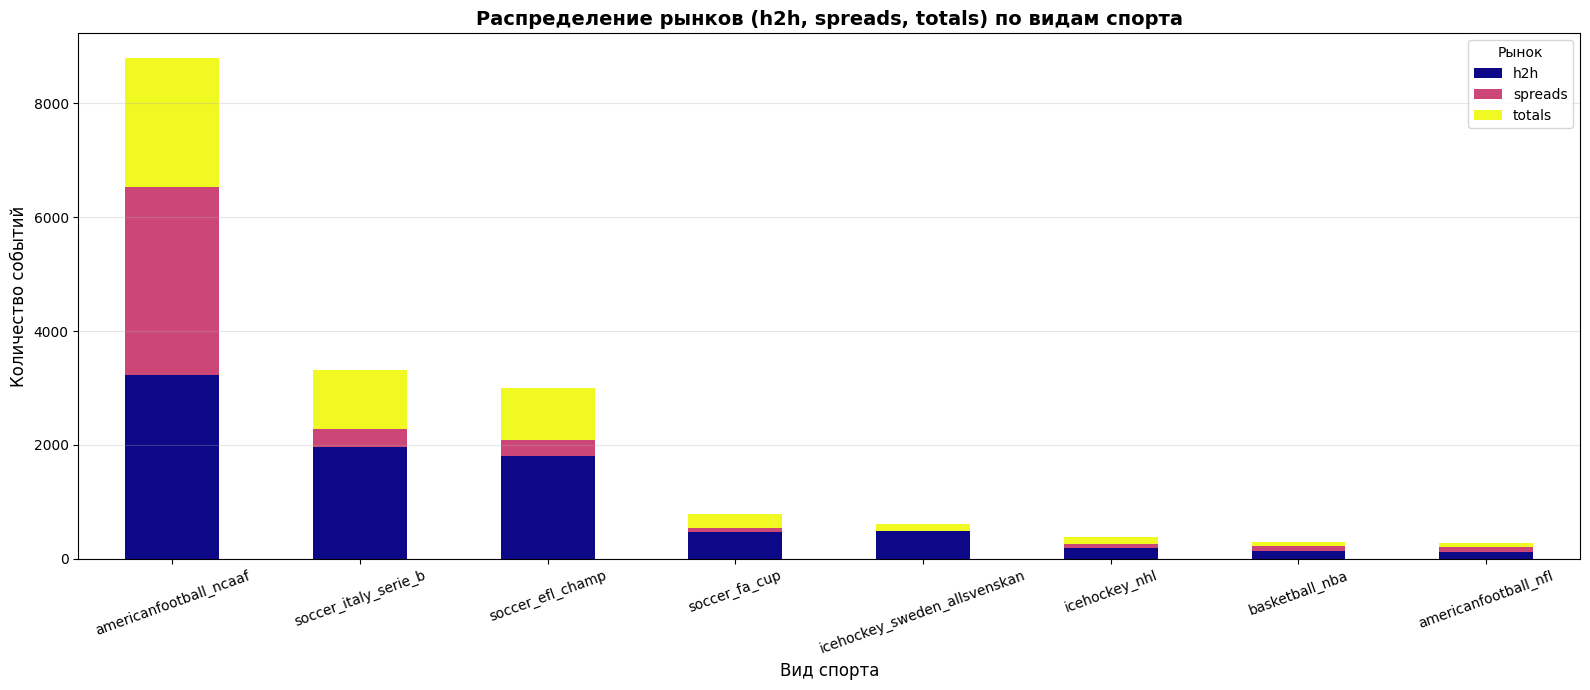

In [ ]:
market_counts = df.groupby(['sport_key', 'market']).size().unstack()

market_counts['total'] = market_counts.sum(axis=1)
market_counts = market_counts.sort_values('total', ascending=False)
market_counts = market_counts.drop(columns='total')
market_counts.plot(kind='bar', stacked=True, figsize=(16,7), colormap='plasma')

plt.ylabel('Количество событий', fontsize=12)
plt.xlabel('Вид спорта', fontsize=12)
plt.title('Распределение рынков (h2h, spreads, totals) по видам спорта', fontsize=14, weight='bold')
plt.xticks(rotation=20)
plt.legend(title='Рынок', fontsize=10)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

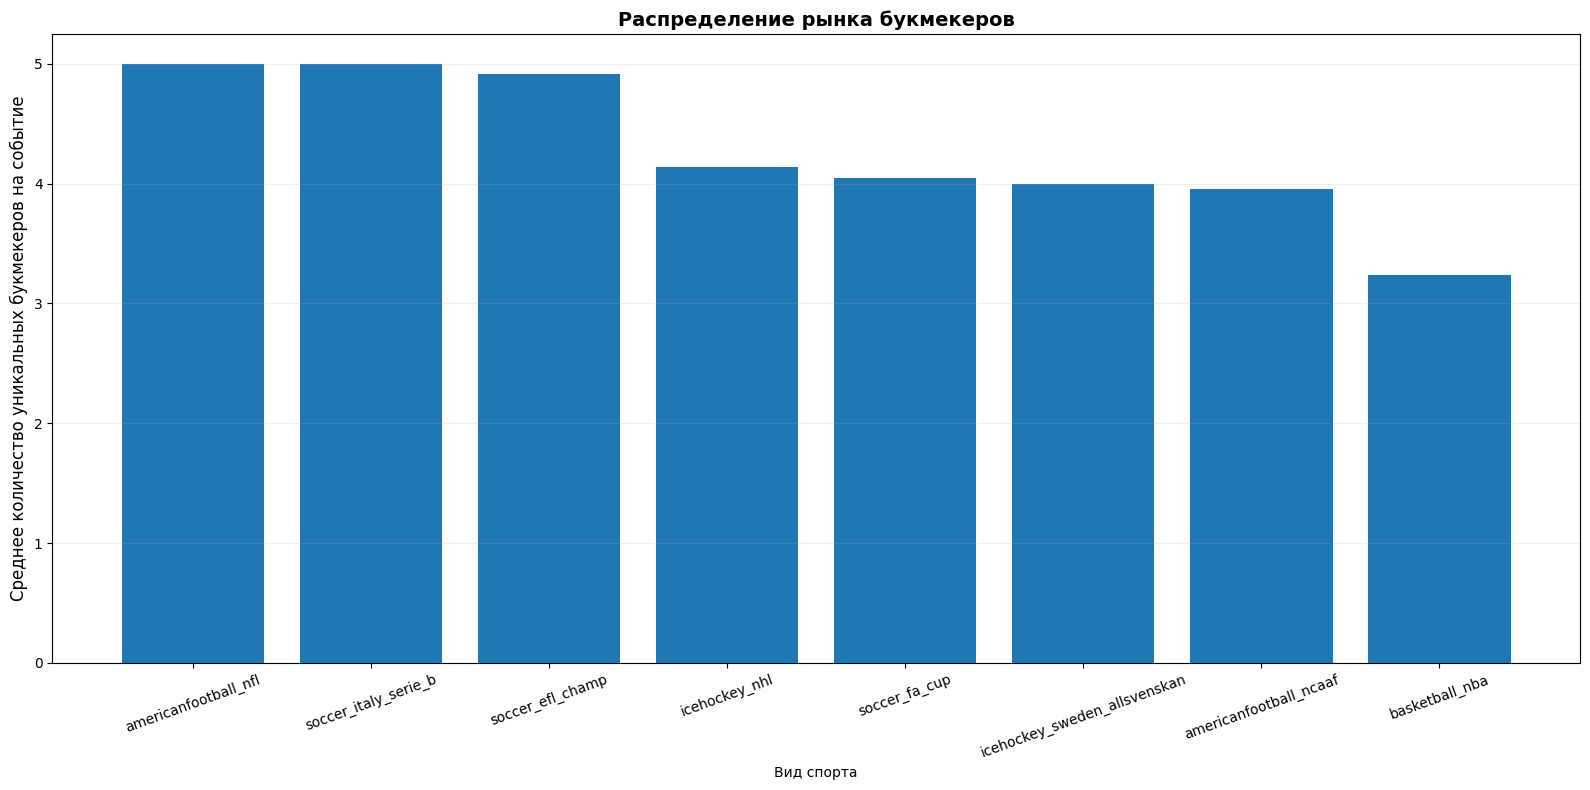

In [ ]:
bookmakers_per_event = df.groupby(['sport_key', 'event_id'])['bookmaker_title'].nunique().reset_index(name='unique_bookmakers')
avg_bookmakers_per_sport = bookmakers_per_event.groupby('sport_key')['unique_bookmakers'].mean().reset_index(name='avg_unique_bookmakers')
avg_bookmakers_per_sport = avg_bookmakers_per_sport.sort_values('avg_unique_bookmakers', ascending=False)
plt.figure(figsize=(16, 8))
plt.bar(avg_bookmakers_per_sport['sport_key'], avg_bookmakers_per_sport['avg_unique_bookmakers'])
plt.xlabel('Вид спорта')
plt.ylabel('Среднее количество уникальных букмекеров на событие', fontsize=12)
plt.title('Распределение рынка букмекеров', fontsize=14, weight='bold')
plt.xticks(rotation=20)
plt.grid(axis='y', alpha=0.2)
plt.tight_layout()
plt.show()

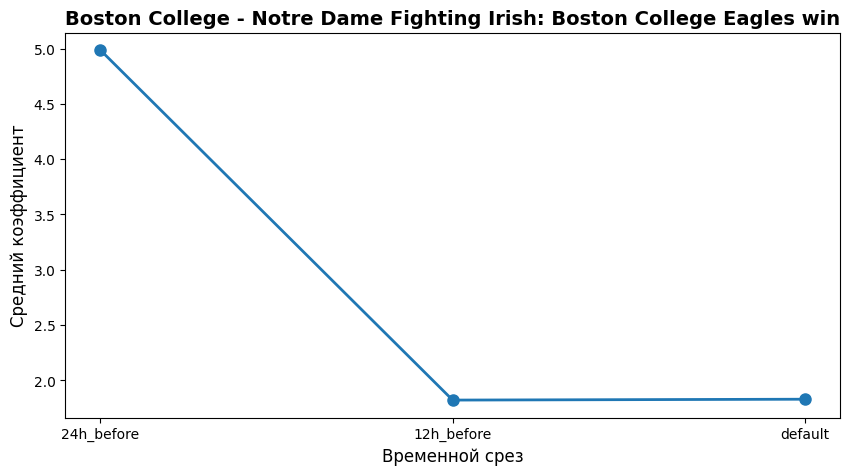

In [ ]:
plt.figure(figsize=(10, 5))
x = ['24h_before', '12h_before', 'default']
y = [df.loc[0]['mean_odds_24h_before'], df.loc[0]['mean_odds_12h_before'], df.loc[0]['mean_odds_default']]
plt.plot(x, y, marker='o', linewidth=2, markersize=8)
plt.title("Boston College - Notre Dame Fighting Irish: Boston College Eagles win", fontsize=14, weight='bold')
plt.xlabel("Временной срез", fontsize=12)
plt.ylabel("Средний коэффициент", fontsize=12);

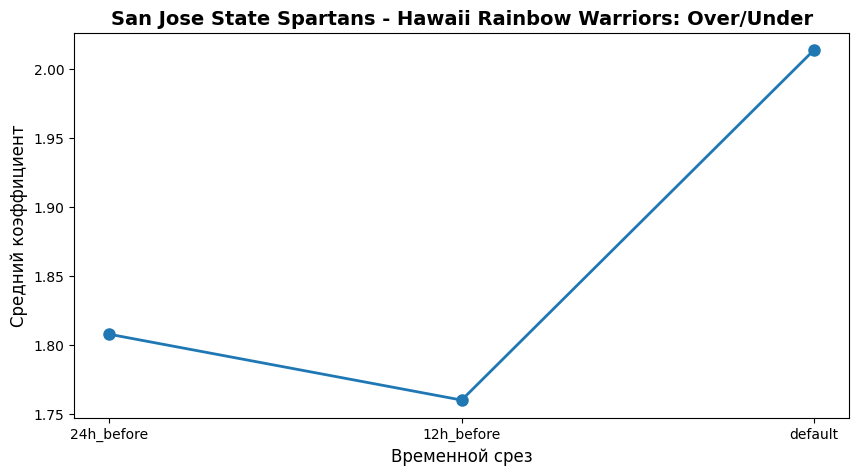

In [ ]:
plt.figure(figsize=(10, 5))
x = ['24h_before', '12h_before', 'default']
y = [df.loc[44]['mean_odds_24h_before'], df.loc[44]['mean_odds_12h_before'], df.loc[44]['mean_odds_default']]
plt.plot(x, y, marker='o', linewidth=2, markersize=8)
plt.title("San Jose State Spartans - Hawaii Rainbow Warriors: Over/Under", fontsize=14, weight='bold')
plt.xlabel("Временной срез", fontsize=12)
plt.ylabel("Средний коэффициент", fontsize=12);

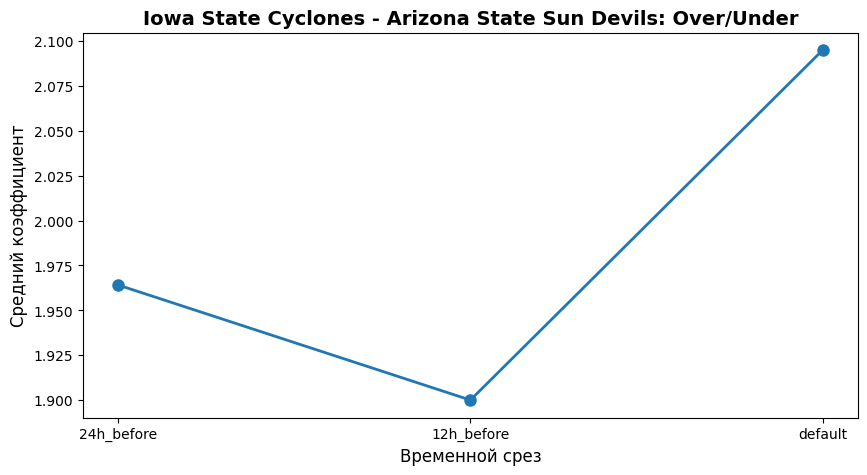

In [ ]:
plt.figure(figsize=(10, 5))
x = ['24h_before', '12h_before', 'default']
y = [df.loc[140]['mean_odds_24h_before'], df.loc[140]['mean_odds_12h_before'], df.loc[140]['mean_odds_default']]
plt.plot(x, y, marker='o', linewidth=2, markersize=8)
plt.title("Iowa State Cyclones - Arizona State Sun Devils: Over/Under", fontsize=14, weight='bold')
plt.xlabel("Временной срез", fontsize=12)
plt.ylabel("Средний коэффициент", fontsize=12);

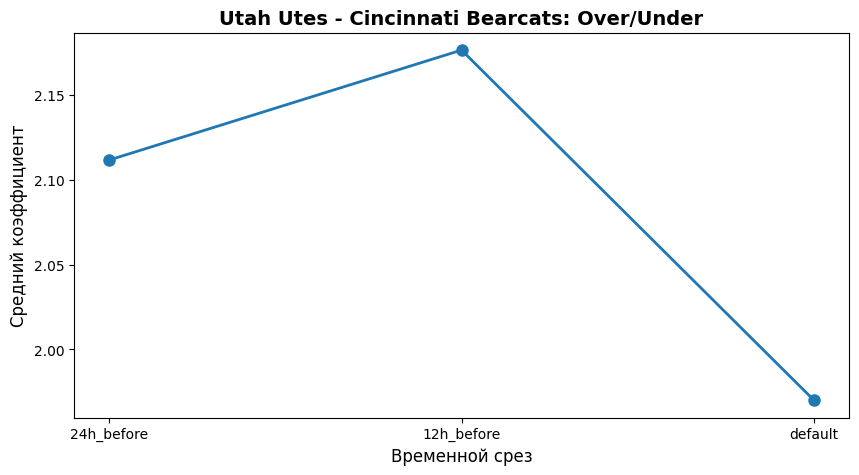

In [ ]:
plt.figure(figsize=(10, 5))
x = ['24h_before', '12h_before', 'default']
y = [df.loc[190]['mean_odds_24h_before'], df.loc[190]['mean_odds_12h_before'], df.loc[190]['mean_odds_default']]
plt.plot(x, y, marker='o', linewidth=2, markersize=8)
plt.title("Utah Utes - Cincinnati Bearcats: Over/Under", fontsize=14, weight='bold')
plt.xlabel("Временной срез", fontsize=12)
plt.ylabel("Средний коэффициент", fontsize=12);

In [ ]:
df = pd.read_csv('experts_top-20251109_000000.csv')
df_top_10 = df[df['Place_in_top'] < 20].reset_index(drop=True)
df_top_av = df[(df['Place_in_top'] > 20) & (df['Place_in_top'] < 100)].reset_index(drop=True)
df_top_worst = df[df['Place_in_top'] > 100].reset_index(drop=True)
ROI = [df_top_10['ROI'].mean(), df_top_av['ROI'].mean(), df_top_worst['ROI'].mean()]
Win_Rate = [df_top_10['Win_Rate'].mean(), df_top_av['Win_Rate'].mean(), df_top_worst['Win_Rate'].mean()]
Avg_Predictions_Per_Day = [df_top_10['Avg_Predictions_Per_Day'].mean(), df_top_av['Avg_Predictions_Per_Day'].mean(), df_top_worst['Avg_Predictions_Per_Day'].mean()]

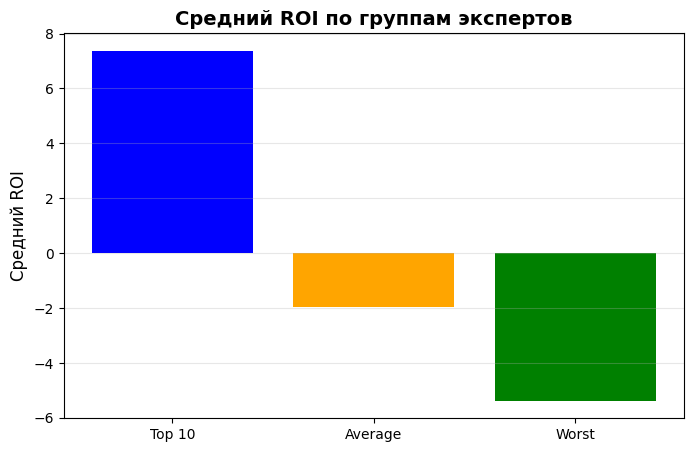

In [ ]:
groups = ['Top 10', 'Average', 'Worst']
plt.figure(figsize=(8,5))
plt.bar(groups, ROI, color=['blue','orange','green'])
plt.ylabel('Средний ROI', fontsize=12)
plt.title('Средний ROI по группам экспертов', fontsize=14, weight='bold')
plt.grid(axis='y', alpha=0.3)
plt.show()

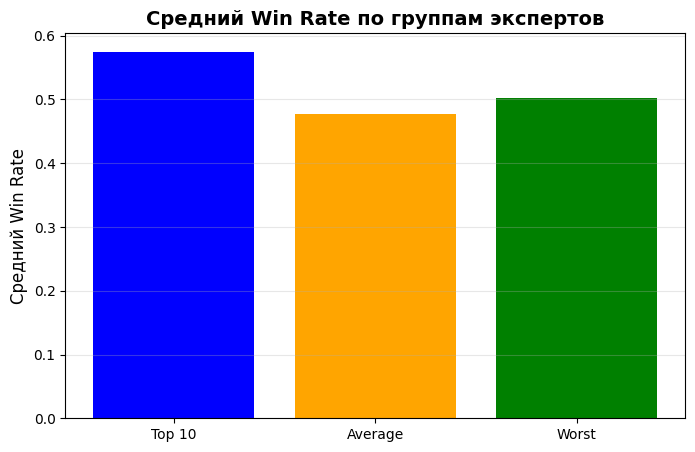

In [ ]:
plt.figure(figsize=(8,5))
plt.bar(groups, Win_Rate, color=['blue','orange','green'])
plt.ylabel('Средний Win Rate', fontsize=12)
plt.title('Средний Win Rate по группам экспертов', fontsize=14, weight='bold')
plt.grid(axis='y', alpha=0.3)
plt.show()

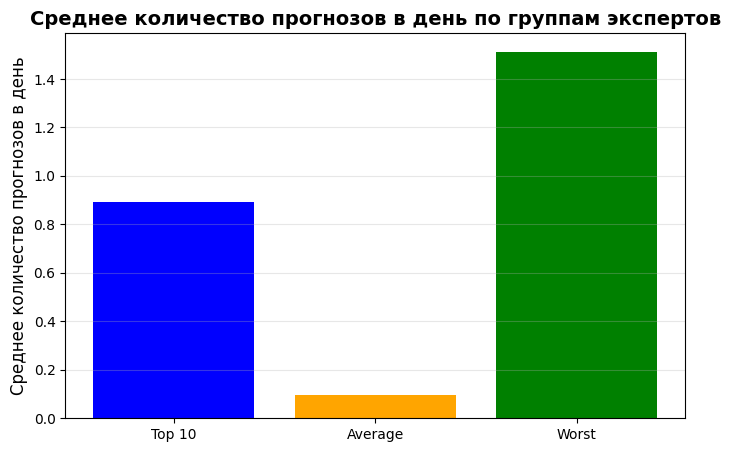

In [ ]:
plt.figure(figsize=(8,5))
plt.bar(groups, Avg_Predictions_Per_Day, color=['blue','orange','green'])
plt.ylabel('Среднее количество прогнозов в день', fontsize=12)
plt.title('Среднее количество прогнозов в день по группам экспертов', fontsize=14, weight='bold')
plt.grid(axis='y', alpha=0.3)
plt.show()